# Section 1 — Génération d'instances VRPTW

Ce notebook explique comment on construit les instances du problème à partir de zéro.

**Fichier source** : `preprocess.py`

---

## Le problème : VRPTW

Le **Vehicle Routing Problem with Time Windows** consiste à :
- Livrer **n clients** depuis un dépôt central
- Avec une flotte de **K véhicules** de capacité limitée
- En respectant des **fenêtres temporelles** `[a_i, b_i]` par client
- En **minimisant la distance totale** parcourue

C'est un problème NP-difficile : pour n=20 clients il existe plus de 20! permutations possibles.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from preprocess import generate_instance, preprocess, verifier_faisabilite, resumer_instance

# Instance de référence utilisée dans tout le notebook
SEED = 42
N    = 10
instance = generate_instance(n=N, seed=SEED)
print(f"Instance créée : {N} clients, seed={SEED}")
print(f"Clés disponibles : {list(instance.keys())}")

Instance créée : 10 clients, seed=42
Clés disponibles : ['n', 'n_vehicles', 'coords', 'dist', 'durees', 'demands', 'capacity', 'time_windows', 'service_times', 'horizon', 'vitesse', 'seed']


## 1. Géographie — coordonnées et distances

`generate_instance()` commence par placer le dépôt et les clients dans l'espace :

```python
depot   = np.array([[50.0, 50.0]])          # Dépôt au centre
clients = rng.uniform(0, 100, size=(n, 2))  # Clients aléatoires dans [0,100]²
coords  = np.concatenate([depot, clients])  # Index 0 = dépôt, 1..n = clients

dist  = np.sqrt(((coords[:,None] - coords[None,:])**2).sum(axis=2))  # Euclidienne
durees = dist * vitesse   # vitesse = 0.6 min/unité
```

La matrice `dist` est de taille **(n+1) × (n+1)** — chaque case `dist[i,j]` est la distance entre le nœud i et le nœud j.

In [3]:
coords = instance['coords']   # shape (n+1, 2)
dist   = instance['dist']     # shape (n+1, n+1)

print(f"coords.shape = {coords.shape}  (0=dépôt, 1..{N}=clients)")
print(f"dist.shape   = {dist.shape}")
print(f"\nDépôt : {coords[0]}")
print(f"Client 1 : {coords[1].round(1)}")
print(f"Distance dépôt→client1 : {dist[0,1]:.2f} unités  ({dist[0,1]*0.6:.1f} min)")
print(f"\nDistance min (hors diag) : {dist[dist>0].min():.1f}")
print(f"Distance max             : {dist.max():.1f}")

coords.shape = (11, 2)  (0=dépôt, 1..10=clients)
dist.shape   = (11, 11)

Dépôt : [50. 50.]
Client 1 : [77.4 43.9]
Distance dépôt→client1 : 28.07 unités  (16.8 min)

Distance min (hors diag) : 7.3
Distance max             : 102.1


## 2. Demandes et capacité des véhicules

Chaque client a une **demande** (quantité à livrer) :

```python
demands[1:] = rng.integers(1, 31, size=n)   # Entier entre 1 et 30
```

La **capacité** de chaque véhicule est calculée pour que la flotte puisse *théoriquement* tout livrer, avec une marge de 40% :

```python
n_vehicles = max(3, ceil(n / 10))           # n=10→3, n=20→3, n=50→5
capacity   = total_demand / n_vehicles * 1.4
```

La marge ×1.4 est nécessaire parce que les véhicules ne peuvent pas toujours remplir leur capacité à 100% à cause des contraintes temporelles.

In [4]:
demands    = instance['demands']      # index 0 = dépôt (demande=0)
capacity   = instance['capacity']
n_vehicles = instance['n_vehicles']

print(f"Nombre de véhicules : {n_vehicles}")
print(f"Capacité par véhicule : {capacity:.1f}")
print(f"Capacité totale flotte : {capacity * n_vehicles:.1f}")
print(f"Demande totale clients : {demands[1:].sum():.1f}")
print(f"Taux de charge : {demands[1:].sum() / (capacity * n_vehicles):.1%}")
print(f"\nDemandes par client :")
for i in range(1, N+1):
    bar = '█' * int(demands[i])
    print(f"  Client {i:2d} : {bar:<30} {int(demands[i]):2d} unités")

Nombre de véhicules : 3
Capacité par véhicule : 84.0
Capacité totale flotte : 252.0
Demande totale clients : 180.0
Taux de charge : 71.4%

Demandes par client :
  Client  1 : █████                           5 unités
  Client  2 : ███████████████████████        23 unités
  Client  3 : ██████████████████████         22 unités
  Client  4 : ███████████                    11 unités
  Client  5 : ███                             3 unités
  Client  6 : ██████████████████████████████ 30 unités
  Client  7 : ██████████████                 14 unités
  Client  8 : ███████████████████████████    27 unités
  Client  9 : █████████████████████          21 unités
  Client 10 : ████████████████████████       24 unités


## 3. Fenêtres temporelles

C'est la contrainte la plus difficile du VRPTW. Chaque client `i` doit être servi entre `a_i` et `b_i` minutes.

On simule **3 profils réels** :

| Profil | Fréquence | Largeur TW | Exemple réel |
|--------|-----------|------------|--------------|
| **Strict** | 40% | 60–90 min | Client avec RDV précis |
| **Modéré** | 40% | 90–150 min | Client disponible demi-journée |
| **Large** | 20% | 200–300 min | Client quasi-toujours disponible |

Règle clé : l'ouverture `a_i` est placée **au plus tôt** au moment où le véhicule peut arriver depuis le dépôt — on ne génère pas de clients inatteignables.

L'horizon total est **480 minutes** (8h de travail).

In [5]:
tw      = instance['time_windows']   # shape (n+1, 2)
horizon = instance['horizon']        # 480 min

largeurs = tw[1:, 1] - tw[1:, 0]
print(f"Horizon : {horizon:.0f} min")
print(f"Largeur TW — min: {largeurs.min():.0f} min  |  moy: {largeurs.mean():.0f} min  |  max: {largeurs.max():.0f} min")
print()

# Classer les clients par largeur de TW
print(f"{'Client':>8} | {'Ouverture':>10} | {'Fermeture':>10} | {'Largeur':>8} | Profil")
print("-" * 60)
for i in range(1, N+1):
    a, b = tw[i]
    larg = b - a
    if larg < 90:
        profil = 'Strict'
    elif larg < 200:
        profil = 'Modéré'
    else:
        profil = 'Large'
    print(f"{i:>8} | {a:>10.1f} | {b:>10.1f} | {larg:>8.1f} | {profil}")

Horizon : 480 min
Largeur TW — min: 60 min  |  moy: 128 min  |  max: 276 min

  Client |  Ouverture |  Fermeture |  Largeur | Profil
------------------------------------------------------------
       1 |      161.0 |      245.2 |     84.2 | Strict
       2 |      281.9 |      350.6 |     68.7 | Strict
       3 |      105.2 |      203.6 |     98.4 | Modéré
       4 |      330.1 |      390.4 |     60.3 | Strict
       5 |      245.2 |      375.1 |    129.9 | Modéré
       6 |      166.2 |      303.1 |    136.9 | Modéré
       7 |       47.4 |      304.3 |    256.9 | Large
       8 |      256.1 |      353.0 |     96.9 | Modéré
       9 |      236.0 |      310.1 |     74.1 | Strict
      10 |      130.8 |      407.2 |    276.4 | Large


## 4. Préprocessing — `preprocess()`

Le modèle PyTorch ne peut pas ingérer des valeurs brutes (distances en km, temps en minutes...) — les gradients exploseraient. `preprocess()` normalise tout dans [0, 1] :

```python
def preprocess(instance) -> np.ndarray:   # shape (n+1, 6)
    coords  / 100.0        # x, y → [0, 1]
    demands / Q            # demande → fraction de capacité
    tw      / T            # fenêtres → fraction de l'horizon
    service / T            # durée service → fraction
```

Résultat : matrice **(n+1) × 6** — une ligne par nœud (dépôt inclus), 6 features par nœud.

Dans `build_decision_dataset.py` on ajoute une 7e colonne : **flag dépôt** (1 pour le nœud 0, 0 pour les clients) → shape **(n+1, 7)**.

In [6]:
node_features = preprocess(instance)   # (n+1, 6)

print(f"node_features.shape = {node_features.shape}")
print(f"\n{'Noeud':>6} | {'x':>6} | {'y':>6} | {'dem/Q':>6} | {'a_i/T':>6} | {'b_i/T':>6} | {'svc/T':>6}")
print("-" * 52)
labels = ['Dépôt'] + [f'Client {i}' for i in range(1, N+1)]
for i, (label, row) in enumerate(zip(labels, node_features)):
    print(f"{label:>8} | {row[0]:>6.3f} | {row[1]:>6.3f} | {row[2]:>6.3f} | {row[3]:>6.3f} | {row[4]:>6.3f} | {row[5]:>6.3f}")

print(f"\nToutes les valeurs dans [0, 1] ? {node_features.min():.3f} .. {node_features.max():.3f}")

node_features.shape = (11, 6)

 Noeud |      x |      y |  dem/Q |  a_i/T |  b_i/T |  svc/T
----------------------------------------------------
   Dépôt |  0.500 |  0.500 |  0.000 |  0.000 |  1.000 |  0.000
Client 1 |  0.774 |  0.439 |  0.060 |  0.335 |  0.511 |  0.014
Client 2 |  0.859 |  0.697 |  0.274 |  0.587 |  0.730 |  0.020
Client 3 |  0.094 |  0.976 |  0.262 |  0.219 |  0.424 |  0.011
Client 4 |  0.761 |  0.786 |  0.131 |  0.688 |  0.813 |  0.014
Client 5 |  0.128 |  0.450 |  0.036 |  0.511 |  0.781 |  0.025
Client 6 |  0.371 |  0.927 |  0.357 |  0.346 |  0.631 |  0.026
Client 7 |  0.644 |  0.823 |  0.167 |  0.099 |  0.634 |  0.031
Client 8 |  0.443 |  0.227 |  0.321 |  0.534 |  0.735 |  0.017
Client 9 |  0.555 |  0.064 |  0.250 |  0.492 |  0.646 |  0.018
Client 10 |  0.828 |  0.632 |  0.286 |  0.273 |  0.848 |  0.020

Toutes les valeurs dans [0, 1] ? 0.000 .. 1.000


## 5. Vérification de faisabilité — `verifier_faisabilite()`

Avant d'envoyer une instance à l'oracle, on vérifie 3 conditions nécessaires :

1. **Atteignabilité** : le dépôt peut-il atteindre chaque client avant sa fermeture `b_i` ?
2. **Capacité totale** : `K × Q ≥ demande totale` ?
3. **Fenêtres valides** : `a_i < b_i` pour tout client ?

> Ces vérifications n'éliminent pas tous les cas infaisables (les contraintes de routage sont plus complexes), mais filtrent les cas trivialement impossibles avant d'appeler OR-Tools.

In [7]:
result = verifier_faisabilite(instance)

print(f"Faisable : {result['faisable']}")
print(f"Clients inatteignables : {result['clients_inatteignables']}")
print(f"Couverture demande OK  : {result['couverture_demande']}")
if result['problemes']:
    print(f"Problèmes : {result['problemes']}")
else:
    print("Aucun problème détecté.")

print()

# Test sur plusieurs tailles
print(f"{'n':>5} | {'Véhicules':>10} | {'Faisable':>9} | {'Inatteignables':>15}")
print("-" * 48)
for n_test in [10, 20, 50, 100]:
    inst = generate_instance(n=n_test, seed=SEED)
    res  = verifier_faisabilite(inst)
    print(f"{n_test:>5} | {inst['n_vehicles']:>10} | {'Oui' if res['faisable'] else 'Non':>9} | {len(res['clients_inatteignables']):>15}")

Faisable : True
Clients inatteignables : []
Couverture demande OK  : True
Aucun problème détecté.

    n |  Véhicules |  Faisable |  Inatteignables
------------------------------------------------
   10 |          3 |       Oui |               0
   20 |          3 |       Oui |               0
   50 |          5 |       Oui |               0
  100 |         10 |       Oui |               0


## 6. Visualisation complète de l'instance

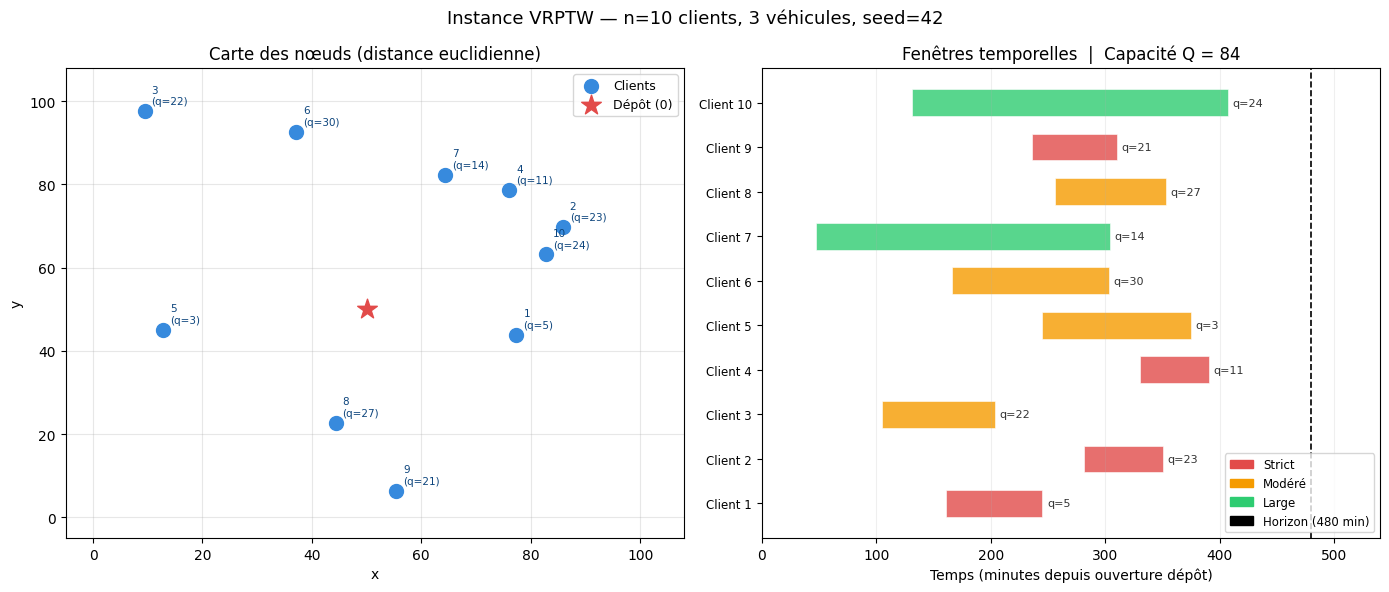

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Instance VRPTW — n={N} clients, {n_vehicles} véhicules, seed={SEED}', fontsize=13)

# ── Panneau gauche : carte géographique ──────────────────────────────────────
ax = axes[0]
ax.scatter(coords[1:, 0], coords[1:, 1],
           c='#378ADD', s=100, zorder=3, label='Clients')
ax.scatter(coords[0, 0], coords[0, 1],
           c='#E24B4A', s=220, marker='*', zorder=4, label='Dépôt (0)')

for i in range(1, N + 1):
    ax.annotate(
        f"{i}\n(q={int(demands[i])})",
        xy=(coords[i, 0], coords[i, 1]),
        xytext=(5, 5), textcoords='offset points',
        fontsize=7.5, color='#0C447C'
    )

ax.set_title('Carte des nœuds (distance euclidienne)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(fontsize=9)
ax.set_xlim(-5, 108)
ax.set_ylim(-5, 108)
ax.grid(True, alpha=0.3)

# ── Panneau droit : fenêtres temporelles ─────────────────────────────────────
ax2 = axes[1]
colors = {'Strict': '#E24B4A', 'Modéré': '#F59B00', 'Large': '#2ECC71'}

for i in range(1, N + 1):
    a, b = tw[i]
    larg = b - a
    profil = 'Strict' if larg < 90 else ('Modéré' if larg < 200 else 'Large')
    ax2.barh(i, b - a, left=a, height=0.6,
             color=colors[profil], alpha=0.8, edgecolor='white', linewidth=0.5)
    ax2.text(b + 4, i, f'q={int(demands[i])}',
             va='center', fontsize=8, color='#333')

ax2.set_yticks(range(1, N + 1))
ax2.set_yticklabels([f'Client {i}' for i in range(1, N + 1)], fontsize=8.5)
ax2.set_xlabel('Temps (minutes depuis ouverture dépôt)')
ax2.set_xlim(0, horizon + 60)
ax2.set_title(f'Fenêtres temporelles  |  Capacité Q = {capacity:.0f}')
ax2.axvline(horizon, color='black', linewidth=1.2, linestyle='--', label=f'Horizon ({int(horizon)} min)')
ax2.grid(True, alpha=0.2, axis='x')

patches = [mpatches.Patch(color=c, label=p) for p, c in colors.items()]
patches.append(mpatches.Patch(color='black', label=f'Horizon ({int(horizon)} min)'))
ax2.legend(handles=patches, fontsize=8.5, loc='lower right')

plt.tight_layout()
plt.show()

## 7. Résumé de l'instance — `resumer_instance()`

In [9]:
resumer_instance(instance)

Instance VRPTW : seed 42
  Clients       : 10
  Véhicules     : 3
  Capacité Q    : 84.0 unités
  Demande tot.  : 180.0 unités
  Horizon       : 480 min
  TW min. larg. : 60.3 min
  TW max. larg. : 276.4 min
  TW moy. larg. : 128.3 min
  Dist. moy.    : 50.8


## 8. Passage à l'échelle

La difficulté du problème explose avec **n** :

| n clients | Véhicules | Décisions oracle (avg) | Complexité combinatoire |
|-----------|-----------|------------------------|-------------------------|
| 10 | 3 | ~10 | 10! ≈ 3.6M |
| 20 | 3 | ~20 | 20! ≈ 2.4×10¹⁸ |
| 50 | 5 | ~50 | 50! ≈ 3×10⁶⁴ |

C'est pourquoi on utilise OR-Tools pour générer les labels optimaux, et qu'on entraîne un modèle de deep learning pour approximer ces solutions en temps réel.

In [10]:
import math

print(f"{'n':>5} | {'Véhicules':>10} | {'Capacité Q':>11} | {'Taux charge':>12}")
print("-" * 46)
for n_test in [10, 20, 50, 100]:
    inst = generate_instance(n=n_test, seed=SEED)
    taux = inst['demands'][1:].sum() / (inst['capacity'] * inst['n_vehicles'])
    print(f"{n_test:>5} | {inst['n_vehicles']:>10} | {inst['capacity']:>11.1f} | {taux:>12.1%}")

    n |  Véhicules |  Capacité Q |  Taux charge
----------------------------------------------
   10 |          3 |        84.0 |        71.4%
   20 |          3 |       160.1 |        71.4%
   50 |          5 |       215.0 |        71.4%
  100 |         10 |       220.2 |        71.4%
